# ODI Batting EDA 

### 1. **Import required libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 2. **Load ODI Batting Dataset**

In [2]:
df = pd.read_csv(r"../Data/Processed/ODI_Batting_Cleaned.csv")
df.head()

,Player,Span,Start_Year,End_Year,Career_Length,Mat,Inns,NO,Runs,HS,...,Ave,BF,SR,100,50,0,Runs_Per_Match,Century_Rate,Fifty_Rate,Consistency_Score
0,SR Tendulkar (INDIA),1989-2012,1989.0,2012.0,24.0,463.0,452.0,41.0,18426.0,200*,...,44.83,21367.0,86.23,49.0,96.0,20.0,39.8,10.58,20.73,61.39
1,KC Sangakkara (Asia/ICC/SL),2000-2015,2000.0,2015.0,16.0,404.0,380.0,41.0,14234.0,169,...,41.98,18048.0,78.86,25.0,93.0,15.0,35.23,6.19,23.02,56.732
2,RT Ponting (AUS/ICC),1995-2012,1995.0,2012.0,18.0,375.0,365.0,39.0,13704.0,164,...,42.03,17046.0,80.39,30.0,82.0,20.0,36.54,8,21.87,57.374
3,ST Jayasuriya (Asia/SL),1989-2011,1989.0,2011.0,23.0,445.0,433.0,18.0,13430.0,189,...,32.36,14725.0,91.2,28.0,68.0,34.0,30.18,6.29,15.28,55.896
4,DPMD Jayawardene (Asia/SL),1998-2015,1998.0,2015.0,18.0,448.0,418.0,39.0,12650.0,144,...,33.37,16020.0,78.96,19.0,77.0,28.0,28.24,4.24,17.19,51.606


### 3. **Dataset Summary**

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(2500, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Player             2490 non-null   object 
 1   Span               2490 non-null   object 
 2   Start_Year         2490 non-null   float64
 3   End_Year           2490 non-null   float64
 4   Career_Length      2490 non-null   float64
 5   Mat                2490 non-null   float64
 6   Inns               2490 non-null   float64
 7   NO                 2490 non-null   float64
 8   Runs               2490 non-null   float64
 9   HS                 2490 non-null   object 
 10  HS_Numeric         2490 non-null   float64
 11  HS_NotOut          2490 non-null   float64
 12  Ave                2490 non-null   object 
 13  BF                 2490 non-null   float64
 14  SR                 2490 non-null   object 
 15  100                2490 non-null   float64
 16  50           

In [31]:
df[df['Player'].isnull()]
df = df.dropna(subset=['Player'])


In [32]:
df.isnull().sum()

Player                 0
Span                   0
Start_Year             0
End_Year               0
Career_Length          0
Mat                    0
Inns                   0
NO                     0
Runs                   0
HS                     0
HS_Numeric             0
HS_NotOut              0
Ave                  120
BF                     0
SR                     9
100                    0
50                     0
0                      0
Runs_Per_Match         0
Century_Rate           0
Fifty_Rate             0
Consistency_Score      0
dtype: int64

In [33]:
corr_cols = ['Ave','SR']
for col in corr_cols:
    df[col] = df[col].replace('-', np.nan)

for i in corr_cols:
    df[i] = pd.to_numeric(df[i], errors='coerce')

### 4. **Visualizations**

##### 1. **Top 10 Run Scorers**

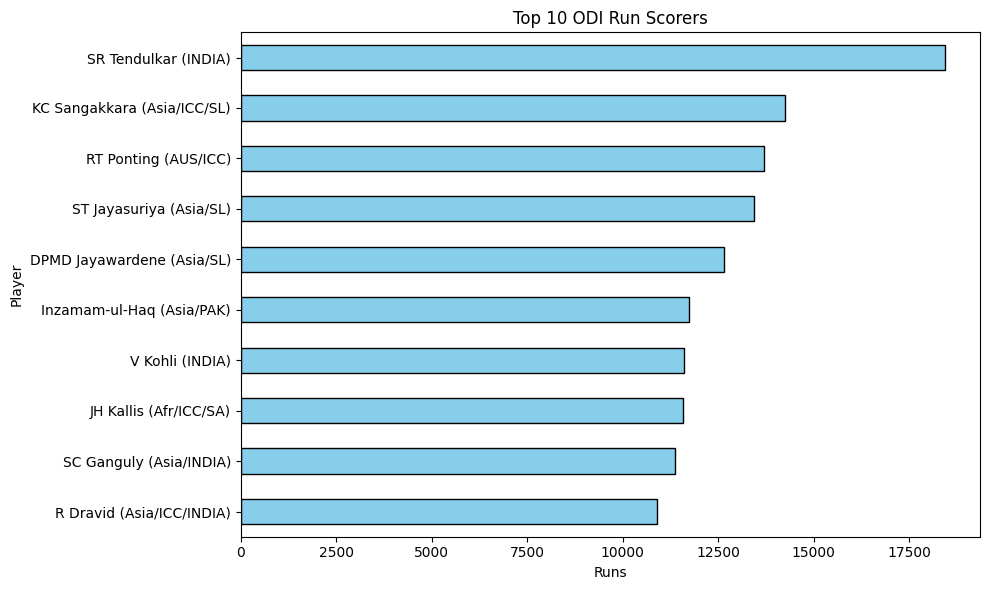

In [34]:
top_runs = (df.groupby('Player')['Runs'].sum().sort_values(ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(10,6))

top_runs.plot(kind='barh',ax=ax, color='skyblue', edgecolor='black')

plt.title('Top 10 ODI Run Scorers')
plt.xlabel('Runs')
plt.ylabel('Player')

plt.tight_layout()
plt.savefig(r'../Images/Top_10_ODI_Run_Scorers.png',dpi=300,bbox_inches='tight')
plt.show()

**Insight:** Sachin Tendulkar stands out as a clear outlier among ODI run scorers, maintaining a significant lead over the second-highest run scorer. In contrast, the gap between players ranked 2nd to 10th is relatively small, indicating a highly competitive group of elite batsmen with comparable career achievements.

##### 2(A). **Top 10 Batting Averages (All Players)**

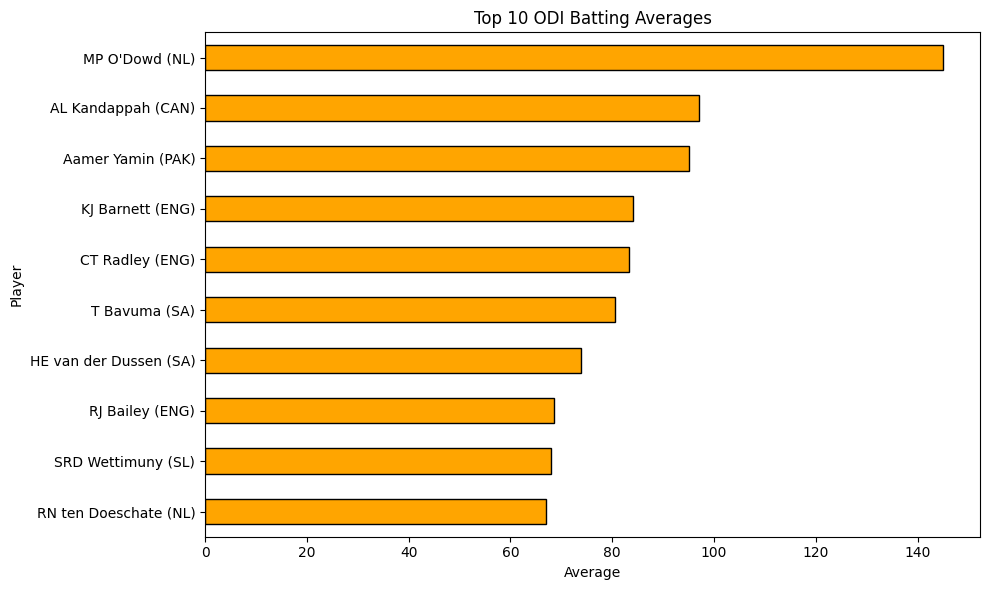

In [35]:
top_ave = (df.groupby('Player')['Ave'].sum().sort_values(ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(10,6))

top_ave.plot(kind='barh',ax=ax, color='orange', edgecolor='black')

plt.title('Top 10 ODI Batting Averages')
plt.xlabel('Average')
plt.ylabel('Player')

plt.tight_layout()
plt.savefig(r'../Images/Top_10_ODI_Batting_Averages1.png',dpi=300,bbox_inches='tight')
plt.show()

In [36]:
df[df['Player'].str.contains("O'Dowd", case=False, na=False)][
    ['Player','Mat','Inns','Runs','Ave','Career_Length']
]

,Player,Mat,Inns,Runs,Ave,Career_Length
1082,MP O'Dowd (NL),2.0,2.0,145.0,145.0,1.0


**Insigh:** MP O'Dowd appears as the player with the highest ODI batting average; however, this figure is based on a very small sample size (only 2 matches). Therefore, the exceptionally high average may not be directly comparable to players who maintained strong averages across long international careers.

##### 2 (B). **Top 10 ODI Batting Averages (Minimum 50 Matches)**

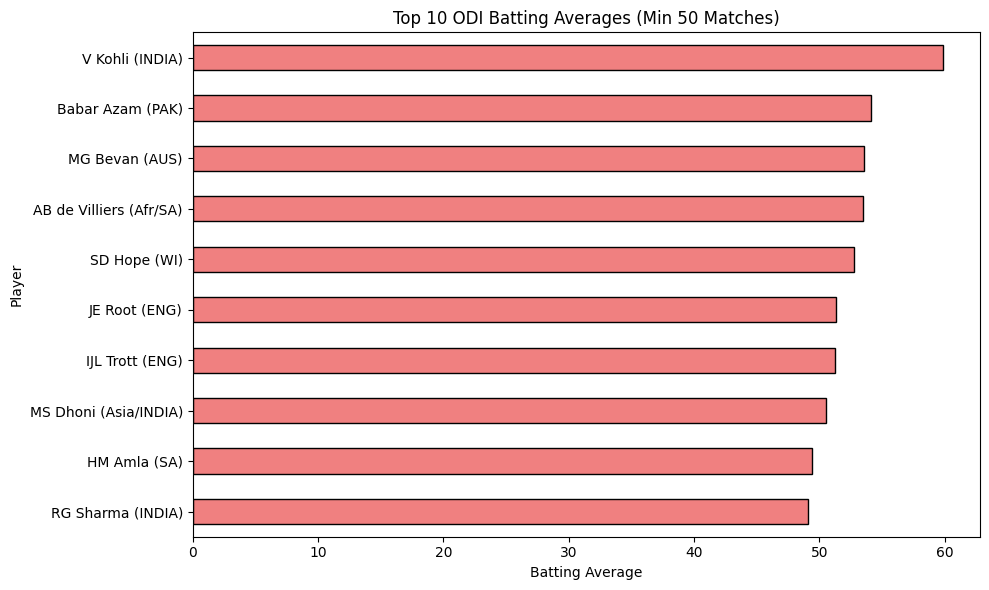

In [37]:
df_filtered = df[df['Mat'] >= 50]

top_avg = (df_filtered.groupby('Player')['Ave'].mean().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10,6))
top_avg.sort_values().plot(kind='barh', ax=ax, color='lightcoral', edgecolor='black')

plt.title('Top 10 ODI Batting Averages (Min 50 Matches)')
plt.xlabel('Batting Average')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig(r'../Images/Top_10_ODI_Batting_Averages2.png',dpi=300,bbox_inches='tight')
plt.show()

**Insight:** After applying a minimum threshold of 50 matches, Virat Kohli emerges as the leading ODI batsman by average, reflecting exceptional consistency across a substantial career. The relatively small gap among the remaining top-ranked players indicates that elite ODI batsmen tend to maintain similar performance levels, with only a few players separating themselves from the pack.

##### 3. **Top 10 players with most centuries**

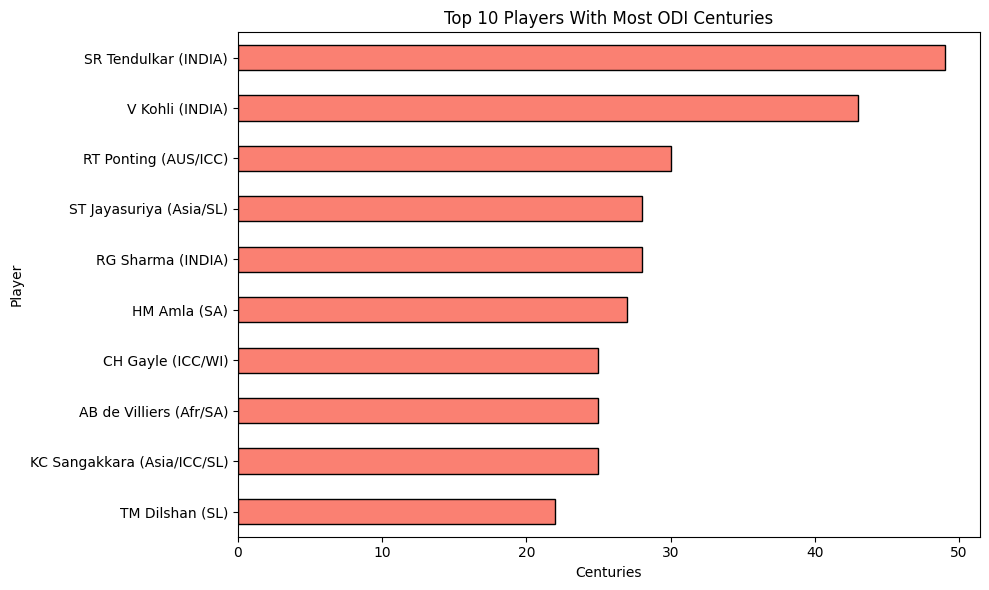

In [38]:
top_centuries = (df.groupby('Player')['100'].sum().sort_values(ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(10,6))

top_centuries.plot(kind='barh',ax=ax, color='salmon', edgecolor='black')
plt.title('Top 10 Players With Most ODI Centuries')
plt.xlabel('Centuries')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig(r'../Images/Top_10_Players_With_Most_ODI_Centuries.png',dpi=300,bbox_inches='tight')
plt.show()

**Insight:** The players with the most centuries are generally among the highest run scorers, indicating a strong relationship between converting starts into big scores and accumulating career runs. Frequent century-making is a key characteristic of elite ODI batsmen.

Modern ODI legends continue to dominate century records, reflecting their ability to score consistently across different playing conditions and eras.

##### 4. **Top 10 players with most half centuries**

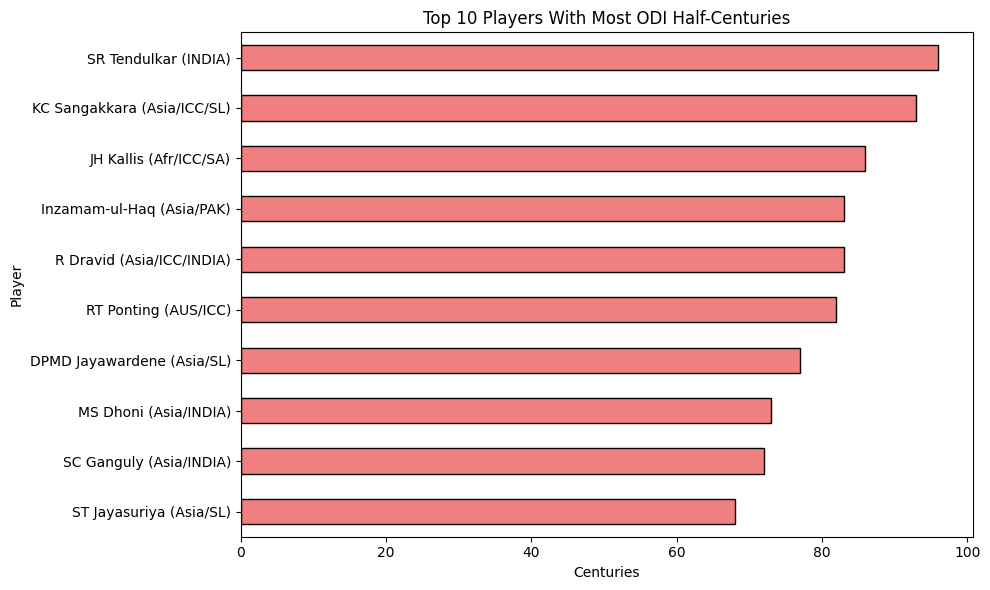

In [39]:
top_half_centuries = (df.groupby('Player')['50'].sum().sort_values(ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(10,6))

top_half_centuries.plot(kind='barh',ax=ax, color='lightcoral', edgecolor='black')
plt.title('Top 10 Players With Most ODI Half-Centuries')
plt.xlabel('Centuries')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig(r'../Images/Top_10_Players_With_Most_ODI_Half_Centuries.png',dpi=300,bbox_inches='tight')
plt.show()

##### 5. **Career Length Distribution**

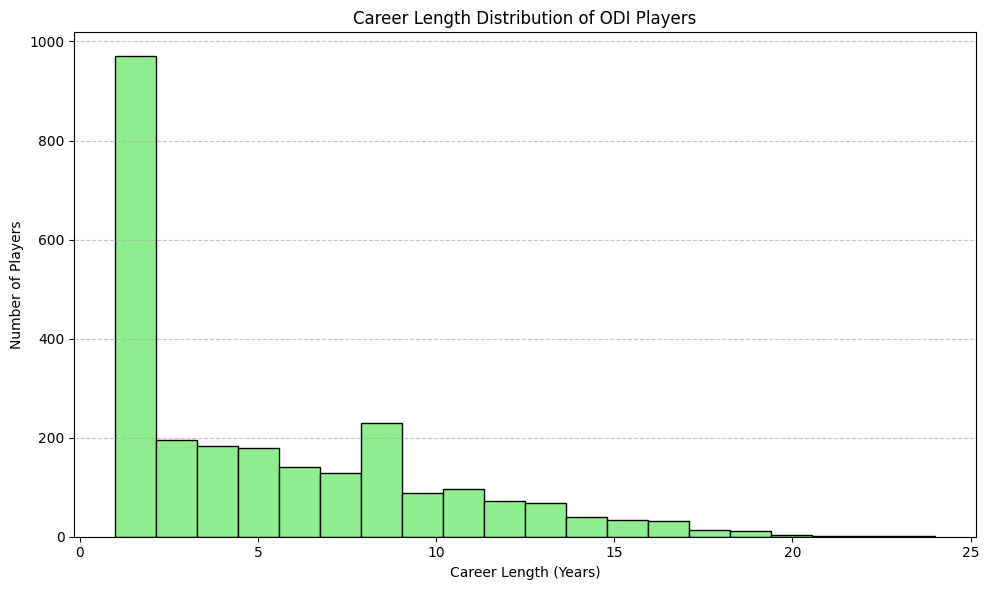

In [40]:
fig, ax = plt.subplots(figsize=(10,6))

df['Career_Length'].plot(kind='hist',bins=20,ax=ax, edgecolor='black', color='lightgreen'
)

plt.title('Career Length Distribution of ODI Players')
plt.xlabel('Career Length (Years)')
plt.ylabel('Number of Players')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(r'../Images/Career_Length_Distribution.png',dpi=300,bbox_inches='tight'
)

plt.show()

**Insight:** The distribution is heavily right-skewed, showing that most ODI players have relatively short international careers, while only a small number sustain careers beyond 10–15 years. Long careers are rare and typically associated with exceptional performance and fitness.

##### 6. **Runs Distribution**

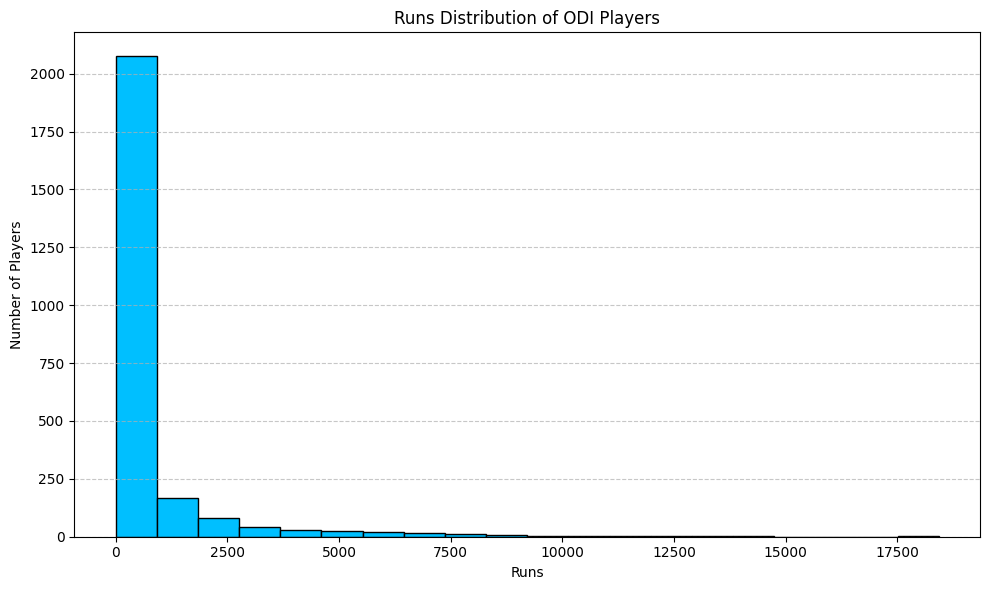

In [41]:
fig, ax = plt.subplots(figsize=(10,6))

df['Runs'].plot(kind='hist',bins=20,ax=ax, edgecolor='black', color='deepskyblue'
)

plt.title('Runs Distribution of ODI Players')
plt.xlabel('Runs')
plt.ylabel('Number of Players')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(r'../Images/Runs_Distribution.png',dpi=300,bbox_inches='tight')

plt.show()

##### 7. **Batting Average Distribution**

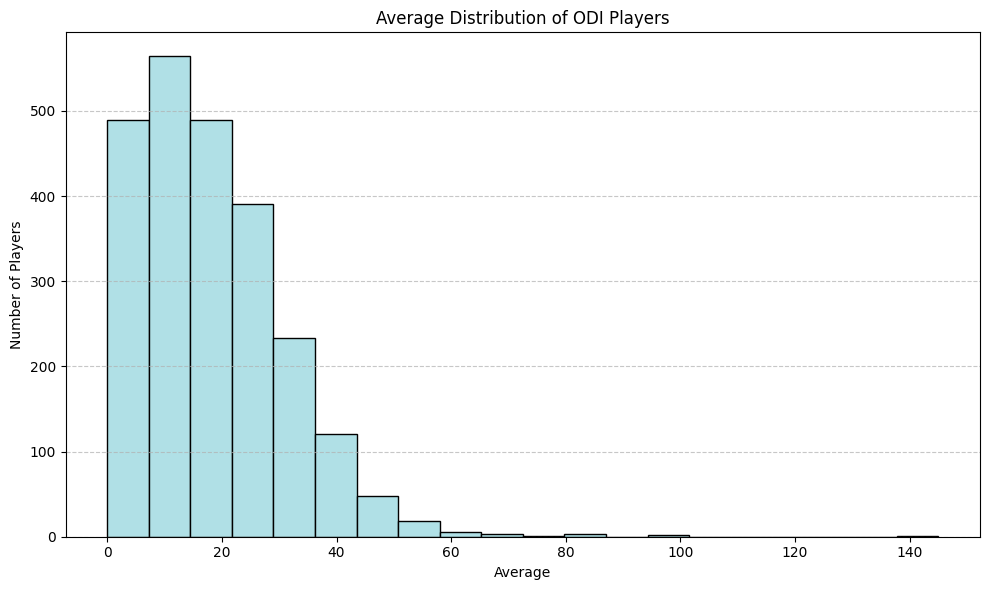

In [42]:
fig, ax = plt.subplots(figsize=(10,6))

df['Ave'].plot(kind='hist',bins=20,ax=ax, edgecolor='black', color='powderblue')

plt.title('Average Distribution of ODI Players')
plt.xlabel('Average')
plt.ylabel('Number of Players')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(r'../Images/Average_Distribution.png',dpi=300,bbox_inches='tight')

plt.show()


##### 8. **Runs vs Average**

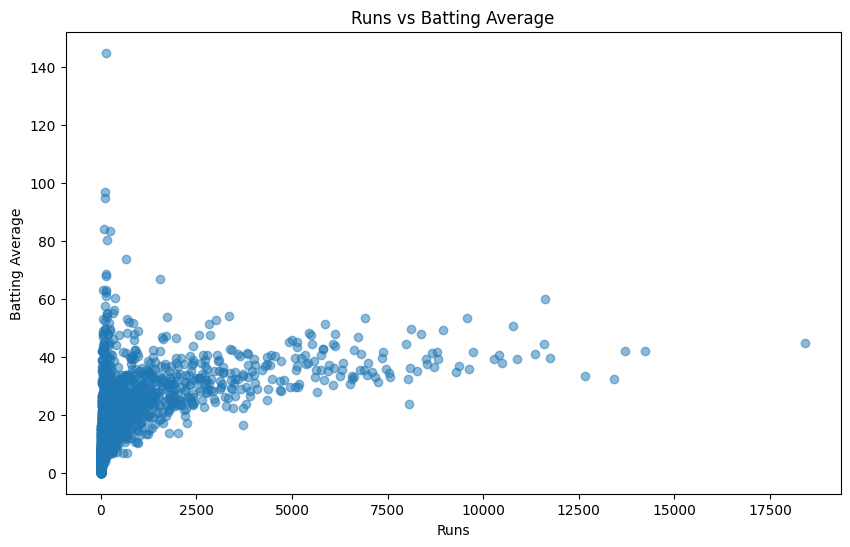

In [43]:
plt.figure(figsize=(10,6))

plt.scatter(df['Runs'],df['Ave'],alpha=0.5)
plt.title('Runs vs Batting Average')
plt.xlabel('Runs')
plt.ylabel('Batting Average')
plt.savefig(r'../Images/Runs_vs_Average.png',dpi=300,bbox_inches='tight')

plt.show()

**INsight:** Most players are clustered between batting averages of 20–40, but their total runs vary widely. This indicates that batting average alone is not the primary factor determining career run accumulation. Players who score the most runs typically combine a good batting average with a long career and a large number of innings. The plot also shows a few outliers with exceptionally high averages but relatively low run totals, suggesting strong performance over a limited number of matches.

##### 9. **Correlation Heatmap**

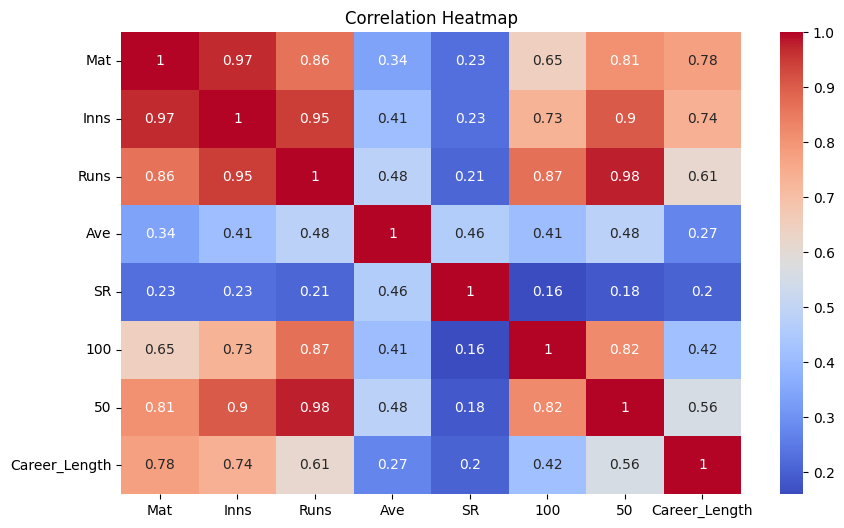

In [44]:
corr_cols = ['Mat','Inns','Runs','Ave','SR','100','50','Career_Length']
for col in corr_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
plt.figure(figsize=(10,6))

sns.heatmap(df[corr_cols].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig(r'../Images/Correlation_Heatmap.png',dpi=300,bbox_inches='tight')

plt.show()


**Insight:** How fast a player scores (Strike Rate) has almost no bearing on how many total runs they score, how many hundreds they make, or how long their career lasts. Fast scoring is an individual playstyle rather than a driver of longevity or total volume.

**The analysis reveals that ODI batting greatness is influenced by both consistency and longevity. While some players achieve exceptional averages over short careers, legends such as Sachin Tendulkar and Virat Kohli combine high efficiency with sustained performance over many years. The EDA demonstrates that career success is not determined by a single metric but by a balance of run accumulation, consistency, century conversion, and career duration.**